<a href="https://colab.research.google.com/github/DoctorNDJonathan/Regression_Climate/blob/main/02_simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — Simple Linear Regression

**Project:** Modelling Global Surface Temperature Change Using Regression  

**Dataset:** NASA GISTEMP v4 — Annual Global Mean Temperature Anomaly (1880–Present)  

**Author:** Nikhil D Jonathan
  
**Environment:** Google Colab (Python 3.10+)

---

### Purpose of this notebook
This notebook tests **Hypothesis H1**:

> *Global mean surface temperature anomaly has a statistically significant positive linear relationship with time (year), meaning temperatures have risen measurably from 1880 to 2024.*

We answer **Research Question RQ1**:

> *Is there a statistically significant linear trend in global temperature anomaly from 1880 to 2024? What is the rate of change per decade?*

### What is simple linear regression?

Simple Linear Regression (SLR) fits a straight line through data with **one predictor** (X) and **one target** (Y):

$$Y = \beta_0 + \beta_1 X + \epsilon$$

Where:
- $\beta_0$ (intercept) = predicted Y when X = 0
- $\beta_1$ (slope) = change in Y for each 1-unit increase in X
- $\epsilon$ (error) = the difference between predicted and actual values

The model finds the line that **minimises the sum of squared errors** — this method is called **Ordinary Least Squares (OLS)**.

### Assumptions of linear regression
Linear regression makes four key assumptions. We will test each one in this notebook:

1. **Linearity** — the relationship between X and Y is approximately linear
2. **Independence** — observations are independent of each other (tested via Durbin-Watson)
3. **Homoscedasticity** — the variance of residuals is constant across all X values
4. **Normality of residuals** — the residuals follow a roughly normal distribution

### Dataset citation
> Lenssen, N., G.A. Schmidt, M. Hendrickson, P. Jacobs, M. Menne, and R. Ruedy, 2024:  
> A GISTEMPv4 observational uncertainty ensemble.  
> *J. Geophys. Res. Atmos.*, 129(17), e2023JD040179.


In [1]:
# =============================================================================
# SECTION 1: IMPORT LIBRARIES
# =============================================================================
# Organised by purpose: data, modelling, evaluation, visualisation, statistics.

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Machine learning ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

# --- Evaluation metrics ---
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --- Statistical tests ---
from scipy import stats

# --- Display settings ---
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [3]:
# =============================================================================
# SECTION 2: CONFIGURATION
# =============================================================================
# Centralised constants — shared across all notebooks for consistency.

# Data source (direct load from NASA — no file upload needed in Colab)
DATA_URL = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# Target column: J-D = January-to-December annual mean anomaly (°C)
TARGET_COL = "J-D"

# Train-test split ratio
TEST_SIZE = 0.2

# Reproducibility seed
RANDOM_STATE = 42

# Cross-validation folds
CV_FOLDS = 10

# Plot colours — consistent palette across all notebooks
COLOR_ACTUAL    = "#3B8BD4"   # blue  — observed data
COLOR_PREDICTED = "#E8593C"   # coral — predictions / trend
COLOR_BASELINE  = "#888780"   # gray  — reference lines
COLOR_RESIDUAL  = "#7B68EE"   # purple — residuals
COLOR_CI        = "#E8593C"   # coral with alpha — confidence interval

print("Configuration set.")
print(f"  Target      : '{TARGET_COL}'")
print(f"  Test size   : {TEST_SIZE*100:.0f}%")
print(f"  CV folds    : {CV_FOLDS}")
print(f"  Random seed : {RANDOM_STATE}")


Configuration set.
  Target      : 'J-D'
  Test size   : 20%
  CV folds    : 10
  Random seed : 42


In [4]:
# =============================================================================
# SECTION 3: DATA LOADING (reused from Notebook 01)
# =============================================================================
# This function is identical to Notebook 01 for reproducibility.
# In a production library, this would live in a shared utils module.

def load_gistemp(url: str) -> pd.DataFrame:
    """
    Load NASA GISTEMP v4 annual temperature anomaly data from CSV URL.

    Handles the NASA CSV quirks:
    - Skips the sub-header row
    - Treats '***' and '****' as missing values
    - Coerces all anomaly columns to numeric
    - Drops rows with missing Year or target values

    Parameters
    ----------
    url : str
        Direct URL to the GISTEMP CSV file.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame sorted by Year.
    """
    df = pd.read_csv(url, skiprows=1, na_values=["***", "****"])

    # Keep relevant columns
    month_cols = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]
    annual_cols = ["J-D", "D-N", "DJF", "MAM", "JJA", "SON"]
    keep = ["Year"] + month_cols + annual_cols
    keep = [c for c in keep if c in df.columns]
    df = df[keep].copy()

    # Clean types
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)
    for col in df.columns:
        if col != "Year":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("Year").reset_index(drop=True)
    return df

# Load and clean
df = load_gistemp(DATA_URL)
df = df.dropna(subset=[TARGET_COL]).copy()

print(f"Data loaded: {len(df)} complete years ({df['Year'].min()}–{df['Year'].max()})")
df.head()


Data loaded: 146 complete years (1880–2025)


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.1900,-0.2500,-0.1000,-0.1700,-0.1000,-0.2100,-0.1900,-0.1100,-0.1500,-0.2400,-0.2200,-0.1900,-0.1800,NaN,NaN,-0.1200,-0.1700,-0.2000
1,1881,-0.2000,-0.1600,0.0200,0.0400,0.0600,-0.1900,0.0100,-0.0400,-0.1500,-0.2200,-0.1900,-0.0700,-0.0900,-0.1000,-0.1800,0.0400,-0.0700,-0.1800
2,1882,0.1600,0.1400,0.0400,-0.1600,-0.1400,-0.2200,-0.1600,-0.0800,-0.1500,-0.2300,-0.1700,-0.3600,-0.1100,-0.0900,0.0800,-0.0800,-0.1500,-0.1800
3,1883,-0.2900,-0.3600,-0.1200,-0.1800,-0.1700,-0.0700,-0.0700,-0.1400,-0.2200,-0.1100,-0.2400,-0.1100,-0.1700,-0.2000,-0.3400,-0.1600,-0.0900,-0.1900
4,1884,-0.1300,-0.0800,-0.3600,-0.4000,-0.3400,-0.3500,-0.3000,-0.2800,-0.2700,-0.2500,-0.3400,-0.3100,-0.2800,-0.2700,-0.1100,-0.3600,-0.3100,-0.2800


---
## Step 1 — Define the predictor (X) and target (Y)

In simple linear regression we have exactly **one predictor**:
- **X** = `Year` — the independent variable (what we use to predict)
- **Y** = `J-D` — the dependent variable (what we are predicting: annual mean temperature anomaly in °C)

The model will learn: **Anomaly = slope × Year + intercept**

The slope tells us how much the temperature anomaly changes per year on average.


In [5]:
# =============================================================================
# SECTION 4: DEFINE FEATURES (X) AND TARGET (Y)
# =============================================================================

def prepare_features(df: pd.DataFrame, feature_cols: list, target_col: str):
    """
    Separate a DataFrame into feature matrix X and target vector y.

    Parameters
    ----------
    df : pd.DataFrame
        The source DataFrame.
    feature_cols : list of str
        Column names to use as predictors.
    target_col : str
        Column name for the target variable.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix (2D — required by scikit-learn).
    y : pd.Series
        Target vector (1D).
    """
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y


# Define X and y
X, y = prepare_features(df, feature_cols=["Year"], target_col=TARGET_COL)

print(f"X shape: {X.shape}  — {X.shape[0]} samples, {X.shape[1]} feature(s)")
print(f"y shape: {y.shape}  — target is '{TARGET_COL}'")
print(f"\nX preview (first 3 rows):")
print(X.head(3).to_string(index=False))
print(f"\ny preview (first 3 values): {y.head(3).tolist()}")


X shape: (146, 1)  — 146 samples, 1 feature(s)
y shape: (146,)  — target is 'J-D'

X preview (first 3 rows):
 Year
 1880
 1881
 1882

y preview (first 3 values): [-0.18, -0.09, -0.11]


---
## Step 2 — Split into training and test sets

We split the data into two parts:
- **Training set (80%)** — the model learns from this data
- **Test set (20%)** — held out to evaluate how well the model generalises to unseen data

**Why split?** If we evaluated the model on the same data it trained on, we would measure memorisation, not learning. The test set simulates "future" data the model has never seen.

**`random_state=42`** ensures the same split every time you run the notebook, making results reproducible.

**Important note:** For time-series data, a random split mixes past and future years together. This is acceptable for this teaching exercise because we are modelling a long-term trend (not forecasting). In Notebook 07 we will also test with a **chronological holdout** (train on 1880–2014, test on 2015–present) for a more realistic evaluation.


In [11]:
# =============================================================================
# SECTION 5: TRAIN-TEST SPLIT
# =============================================================================

def split_data(X, y, test_size=0.2, random_state=42):
    """
    Split features and target into training and test sets.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Target vector.
    test_size : float
        Proportion of data reserved for testing (0.0 to 1.0).
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state  # BUG FIX
    )
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(X, y, TEST_SIZE, RANDOM_STATE)

# --- Clear, unambiguous output ---
print(f"Training set : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

# Show that random split scatters test years across the full range
test_years_sorted = sorted(X_test['Year'].values)
print(f"\nTest set years ({len(test_years_sorted)} randomly selected):")
print(f"  {test_years_sorted}")
print(f"\nNote: Random split selects individual years at random, NOT a")
print(f"contiguous block. Years are scattered across the full range.")
print(f"For chronological evaluation, see Notebook 07.")


Training set : 116 samples (79%)
Test set     : 30 samples (21%)

Test set years (30 randomly selected):
  [np.int64(1889), np.int64(1891), np.int64(1892), np.int64(1898), np.int64(1899), np.int64(1907), np.int64(1909), np.int64(1910), np.int64(1911), np.int64(1916), np.int64(1922), np.int64(1925), np.int64(1935), np.int64(1940), np.int64(1944), np.int64(1946), np.int64(1947), np.int64(1958), np.int64(1960), np.int64(1973), np.int64(1976), np.int64(1977), np.int64(1981), np.int64(1994), np.int64(1995), np.int64(2000), np.int64(2002), np.int64(2017), np.int64(2019), np.int64(2021)]

Note: Random split selects individual years at random, NOT a
contiguous block. Years are scattered across the full range.
For chronological evaluation, see Notebook 07.


---
## Step 3 — Train the simple linear regression model

Scikit-learn's `LinearRegression` uses the **Ordinary Least Squares (OLS)** method. OLS finds the slope ($\beta_1$) and intercept ($\beta_0$) that minimise the **sum of squared residuals**:

$$\text{minimise} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Where $y_i$ is the actual value and $\hat{y}_i = \beta_0 + \beta_1 x_i$ is the predicted value.

Training happens in a single `.fit()` call. After training, we can inspect:
- **Coefficient (slope):** how much the anomaly changes per year
- **Intercept:** the predicted anomaly when Year = 0 (not physically meaningful, but mathematically necessary)


In [12]:
# =============================================================================
# SECTION 6: TRAIN THE MODEL
# =============================================================================

def train_linear_model(X_train, y_train):
    """
    Train a simple linear regression model using OLS.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target.

    Returns
    -------
    model : LinearRegression
        The fitted model object.
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


# Train
model = train_linear_model(X_train, y_train)

# Extract and display the learned parameters
slope = model.coef_[0]
intercept = model.intercept_

print("=" * 60)
print("MODEL TRAINED — Ordinary Least Squares (OLS)")
print("=" * 60)
print(f"  Equation    : Anomaly = {slope:.6f} × Year + ({intercept:.4f})")
print(f"  Slope       : {slope:.6f} °C per year")
print(f"  Per decade  : {slope * 10:.4f} °C per decade")
print(f"  Per century : {slope * 100:.4f} °C per century")
print(f"  Intercept   : {intercept:.4f}")
print()
print("INTERPRETATION:")
print(f"  On average, the global temperature anomaly has increased by")
print(f"  approximately {slope * 10:.3f}°C every 10 years since 1880.")


MODEL TRAINED — Ordinary Least Squares (OLS)
  Equation    : Anomaly = 0.008194 × Year + (-15.9174)
  Slope       : 0.008194 °C per year
  Per decade  : 0.0819 °C per decade
  Per century : 0.8194 °C per century
  Intercept   : -15.9174

INTERPRETATION:
  On average, the global temperature anomaly has increased by
  approximately 0.082°C every 10 years since 1880.


---
## Step 4 — Generate predictions

We generate predictions for:
1. **Training set** — to see how well the model fits the data it learned from
2. **Test set** — to evaluate generalisation (this is the metric that matters)
3. **Full dataset** — for visualisation of the regression line across all years


In [13]:
# =============================================================================
# SECTION 7: GENERATE PREDICTIONS
# =============================================================================

def predict(model, X):
    """Generate predictions from a trained model."""
    return model.predict(X)


# Predictions on each set
y_train_pred = predict(model, X_train)
y_test_pred  = predict(model, X_test)
y_full_pred  = predict(model, X)       # for plotting the regression line

# Also predict specific future years for demonstration
future_years = pd.DataFrame({"Year": [2030, 2040, 2050]})
future_preds = predict(model, future_years)

print("Sample predictions on test set (first 10):")
comparison = pd.DataFrame({
    "Year": X_test["Year"].values,
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Error": y_test.values - y_test_pred
}).sort_values("Year").head(10)
print(comparison.to_string(index=False))

print(f"\nFuture projections (extrapolation — use with caution):")
for yr, pred in zip(future_years["Year"], future_preds):
    print(f"  {yr}: {pred:.3f} °C anomaly")


Sample predictions on test set (first 10):
 Year  Actual  Predicted   Error
 1889 -0.1100    -0.4380  0.3280
 1891 -0.2200    -0.4216  0.2016
 1892 -0.2700    -0.4135  0.1435
 1898 -0.2800    -0.3643  0.0843
 1899 -0.1800    -0.3561  0.1761
 1907 -0.3900    -0.2905 -0.0995
 1909 -0.4900    -0.2741 -0.2159
 1910 -0.4400    -0.2660 -0.1740
 1911 -0.4500    -0.2578 -0.1922
 1916 -0.3600    -0.2168 -0.1432

Future projections (extrapolation — use with caution):
  2030: 0.717 °C anomaly
  2040: 0.799 °C anomaly
  2050: 0.881 °C anomaly


---
## Step 5 — Evaluate model performance

We compute five metrics. Each tells a different part of the story:

| Metric | What it measures | Ideal value |
|---|---|---|
| **R²** (R-squared) | Proportion of variance in Y explained by X. 1.0 = perfect. | Closer to 1.0 |
| **Adjusted R²** | R² penalised for number of features. Prevents rewarding complexity. | Closer to 1.0 |
| **RMSE** | Average prediction error in the same units as Y (°C). | As low as possible |
| **MAE** | Median-like average error. Less sensitive to outliers than RMSE. | As low as possible |
| **MAPE** | Error as a percentage of actual values. Intuitive but unstable near zero. | As low as possible |

**Critical rule:** We report metrics on the **test set**, not the training set. Training metrics measure memorisation; test metrics measure learning.


In [10]:
# =============================================================================
# SECTION 8: EVALUATION METRICS
# =============================================================================

def evaluate_model(y_true, y_pred, n_features=1, dataset_name="Test"):
    """
    Compute and display regression evaluation metrics.

    Parameters
    ----------
    y_true : array-like
        Actual target values.
    y_pred : array-like
        Predicted target values.
    n_features : int
        Number of features (for adjusted R²).
    dataset_name : str
        Label for display (e.g. 'Train', 'Test').

    Returns
    -------
    metrics : dict
        Dictionary of computed metrics.
    """
    n = len(y_true)
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)

    # Adjusted R² — penalises adding features that don't help
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    # MAPE — handle zero values gracefully
    non_zero = np.abs(y_true) > 0.001
    if non_zero.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero])
                              / y_true[non_zero])) * 100
    else:
        mape = np.nan

    metrics = {
        "R²": r2,
        "Adjusted R²": adj_r2,
        "RMSE (°C)": rmse,
        "MAE (°C)": mae,
        "MAPE (%)": mape
    }

    print(f"\n{'='*60}")
    print(f"EVALUATION METRICS — {dataset_name} Set")
    print(f"{'='*60}")
    for name, value in metrics.items():
        print(f"  {name:15s}: {value:.4f}")

    return metrics


# Evaluate on BOTH sets for comparison
print("Comparing training vs test performance:")
print("(Large gap = overfitting; similar values = good generalisation)")

train_metrics = evaluate_model(y_train, y_train_pred,
                                n_features=1, dataset_name="Training")
test_metrics  = evaluate_model(y_test, y_test_pred,
                                n_features=1, dataset_name="Test")

# Check for overfitting
r2_gap = train_metrics["R²"] - test_metrics["R²"]
print(f"\nR² gap (train - test): {r2_gap:.4f}")
if abs(r2_gap) < 0.05:
    print("→ Minimal gap — no overfitting detected.")
elif r2_gap > 0.1:
    print("→ Large gap — possible overfitting. Consider regularisation.")
else:
    print("→ Small gap — acceptable.")


Comparing training vs test performance:
(Large gap = overfitting; similar values = good generalisation)

EVALUATION METRICS — Training Set
  R²             : 0.7539
  Adjusted R²    : 0.7517
  RMSE (°C)      : 0.1977
  MAE (°C)       : 0.1588
  MAPE (%)       : 158.2558

EVALUATION METRICS — Test Set
  R²             : 0.8044
  Adjusted R²    : 0.7974
  RMSE (°C)      : 0.1780
  MAE (°C)       : 0.1533
  MAPE (%)       : 102.6664

R² gap (train - test): -0.0505
→ Small gap — acceptable.


---
## Step 6 — Cross-validation

A single train-test split is dependent on which particular rows land in each set. **K-fold cross-validation** gives a more robust estimate by:

1. Splitting data into K equal folds
2. Training on K-1 folds, testing on the remaining 1
3. Repeating K times, each fold serving as the test set once
4. Averaging the K scores

We use **10-fold CV**, which means 10 different train-test combinations. The mean and standard deviation of the scores tell us how stable the model is.

> **Reference:** Berrar, D. (2019). Cross-validation. *Encyclopedia of Bioinformatics and Computational Biology*, 1, 542–545. Elsevier.


In [14]:
# =============================================================================
# SECTION 9: K-FOLD CROSS-VALIDATION
# =============================================================================

def run_cross_validation(model_class, X, y, cv_folds=10, random_state=42):
    """
    Perform K-fold cross-validation and report results.

    Parameters
    ----------
    model_class : class
        Scikit-learn model class (e.g. LinearRegression).
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Target vector.
    cv_folds : int
        Number of cross-validation folds.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    cv_results : dict
        Contains individual fold scores, mean, and std.
    """
    model = model_class()

    # Scoring: neg_mean_squared_error (sklearn convention: higher is better)
    mse_scores = cross_val_score(model, X, y, cv=cv_folds,
                                  scoring='neg_mean_squared_error')
    r2_scores  = cross_val_score(model, X, y, cv=cv_folds,
                                  scoring='r2')

    rmse_scores = np.sqrt(-mse_scores)

    cv_results = {
        "rmse_scores": rmse_scores,
        "r2_scores": r2_scores,
        "rmse_mean": rmse_scores.mean(),
        "rmse_std": rmse_scores.std(),
        "r2_mean": r2_scores.mean(),
        "r2_std": r2_scores.std()
    }

    print(f"\n{'='*60}")
    print(f"{cv_folds}-FOLD CROSS-VALIDATION RESULTS")
    print(f"{'='*60}")
    print(f"  RMSE : {cv_results['rmse_mean']:.4f} ± {cv_results['rmse_std']:.4f} °C")
    print(f"  R²   : {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
    print(f"\n  Per-fold RMSE: {np.round(rmse_scores, 4).tolist()}")
    print(f"  Per-fold R²  : {np.round(r2_scores, 4).tolist()}")

    return cv_results


cv_results = run_cross_validation(LinearRegression, X, y,
                                   cv_folds=CV_FOLDS,
                                   random_state=RANDOM_STATE)



10-FOLD CROSS-VALIDATION RESULTS
  RMSE : 0.2175 ± 0.1154 °C
  R²   : -3.3059 ± 4.1852

  Per-fold RMSE: [0.3608, 0.1799, 0.1436, 0.1125, 0.1438, 0.2366, 0.2378, 0.1437, 0.1256, 0.4905]
  Per-fold R²  : [-14.1624, -0.9949, -1.1868, -0.3789, -0.5802, -6.0509, -2.0381, -0.7497, -0.6529, -6.2646]


---
## Step 7 — Statistical significance of the slope

A positive slope alone does not prove a real trend — it could be random noise. We need a **hypothesis test**:

- **Null hypothesis (H₀):** The slope is zero — there is no linear relationship between Year and temperature anomaly.
- **Alternative hypothesis (H₁):** The slope is not zero — a significant linear trend exists.

We use the **t-test** on the slope coefficient. If the **p-value < 0.05**, we reject H₀ and conclude the trend is statistically significant.

We also compute a **95% confidence interval** for the slope — the range within which the true slope likely falls.


In [15]:
# =============================================================================
# SECTION 10: STATISTICAL SIGNIFICANCE TEST
# =============================================================================

def test_slope_significance(X, y, feature_name="Year"):
    """
    Test whether the regression slope is statistically significant
    using scipy's linregress (which provides t-test and p-value).

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (single column for SLR).
    y : pd.Series
        Target vector.
    feature_name : str
        Name of the feature column.

    Returns
    -------
    results : dict
        slope, intercept, r_value, p_value, std_err, ci_lower, ci_upper
    """
    x_vals = X[feature_name].values
    y_vals = y.values

    # scipy.stats.linregress gives us the t-test for free
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)

    # 95% confidence interval for the slope
    n = len(x_vals)
    t_critical = stats.t.ppf(0.975, df=n-2)  # two-tailed, 95%
    ci_lower = slope - t_critical * std_err
    ci_upper = slope + t_critical * std_err

    results = {
        "slope": slope,
        "intercept": intercept,
        "r_value": r_value,
        "r_squared": r_value**2,
        "p_value": p_value,
        "std_err": std_err,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "t_statistic": slope / std_err,
        "n": n
    }

    print(f"\n{'='*60}")
    print(f"STATISTICAL SIGNIFICANCE TEST — Slope of {feature_name}")
    print(f"{'='*60}")
    print(f"  Null hypothesis H₀ : slope = 0 (no linear trend)")
    print(f"  Alt. hypothesis H₁ : slope ≠ 0 (trend exists)")
    print(f"")
    print(f"  Slope         : {slope:.6f} °C/year")
    print(f"  Std error     : {std_err:.6f}")
    print(f"  t-statistic   : {results['t_statistic']:.2f}")
    print(f"  p-value       : {p_value:.2e}")
    print(f"  95% CI        : [{ci_lower:.6f}, {ci_upper:.6f}] °C/year")
    print(f"  Pearson r     : {r_value:.4f}")
    print(f"  R²            : {r_value**2:.4f}")
    print()

    if p_value < 0.001:
        print("  CONCLUSION: Slope is highly significant (p < 0.001).")
        print("  → We REJECT H₀. There IS a statistically significant warming trend.")
    elif p_value < 0.05:
        print("  CONCLUSION: Slope is significant at α = 0.05.")
        print("  → We REJECT H₀.")
    else:
        print("  CONCLUSION: Slope is NOT significant at α = 0.05.")
        print("  → We FAIL TO REJECT H₀.")

    return results


sig_results = test_slope_significance(X, y, feature_name="Year")



STATISTICAL SIGNIFICANCE TEST — Slope of Year
  Null hypothesis H₀ : slope = 0 (no linear trend)
  Alt. hypothesis H₁ : slope ≠ 0 (trend exists)

  Slope         : 0.008295 °C/year
  Std error     : 0.000383
  t-statistic   : 21.65
  p-value       : 3.98e-47
  95% CI        : [0.007537, 0.009052] °C/year
  Pearson r     : 0.8746
  R²            : 0.7650

  CONCLUSION: Slope is highly significant (p < 0.001).
  → We REJECT H₀. There IS a statistically significant warming trend.


---
## Step 8 — Residual analysis (testing regression assumptions)

**Residuals** = Actual − Predicted. They are the errors left over after the model has done its best.

A well-behaved model should produce residuals that are:
1. **Randomly scattered** around zero (no pattern) → confirms linearity
2. **Constant spread** across all X values → confirms homoscedasticity
3. **Approximately normally distributed** → validates confidence intervals
4. **Not correlated with each other** → confirms independence (Durbin-Watson test)

If residuals show a pattern (e.g. a curve), the model is missing something — a sign that polynomial regression (Notebook 04) might be needed.


In [16]:
# =============================================================================
# SECTION 11: RESIDUAL ANALYSIS
# =============================================================================

def compute_residuals(y_true, y_pred):
    """Compute residuals (actual - predicted)."""
    return np.array(y_true) - np.array(y_pred)


def analyse_residuals(X_test, y_test, y_pred, feature_name="Year"):
    """
    Comprehensive residual analysis: compute residuals and run diagnostic
    tests for the four OLS assumptions.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        Actual test values.
    y_pred : array-like
        Predicted test values.
    feature_name : str
        Name of the feature column.

    Returns
    -------
    diagnostics : dict
        Results of all diagnostic tests.
    """
    residuals = compute_residuals(y_test, y_pred)

    # --- Test 1: Normality (Shapiro-Wilk) ---
    shapiro_stat, shapiro_p = stats.shapiro(residuals)

    # --- Test 2: Autocorrelation (Durbin-Watson) ---
    # DW ≈ 2 means no autocorrelation
    # DW < 1.5 → positive autocorrelation
    # DW > 2.5 → negative autocorrelation
    sorted_idx = np.argsort(X_test[feature_name].values)
    sorted_residuals = residuals[sorted_idx]
    dw_stat = np.sum(np.diff(sorted_residuals)**2) / np.sum(sorted_residuals**2)

    # --- Test 3: Homoscedasticity (Breusch-Pagan style — correlation of |residuals| with X) ---
    bp_corr, bp_p = stats.pearsonr(X_test[feature_name].values, np.abs(residuals))

    # --- Basic residual statistics ---
    diagnostics = {
        "mean": residuals.mean(),
        "std": residuals.std(),
        "min": residuals.min(),
        "max": residuals.max(),
        "shapiro_stat": shapiro_stat,
        "shapiro_p": shapiro_p,
        "durbin_watson": dw_stat,
        "bp_corr": bp_corr,
        "bp_p": bp_p,
        "residuals": residuals
    }

    print(f"\n{'='*60}")
    print("RESIDUAL DIAGNOSTICS")
    print(f"{'='*60}")
    print(f"  Mean residual     : {residuals.mean():.6f}  (should be ≈ 0)")
    print(f"  Std of residuals  : {residuals.std():.4f} °C")
    print(f"  Min residual      : {residuals.min():.4f} °C")
    print(f"  Max residual      : {residuals.max():.4f} °C")
    print()

    # Normality
    print(f"  Shapiro-Wilk test : stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("    → Residuals are approximately normal (p > 0.05) ✓")
    else:
        print("    → Residuals are NOT normal (p ≤ 0.05) ✗")
        print("      (Common for time-series data; monitor but not fatal)")
    print()

    # Autocorrelation
    print(f"  Durbin-Watson     : {dw_stat:.4f}  (ideal ≈ 2.0)")
    if 1.5 <= dw_stat <= 2.5:
        print("    → No significant autocorrelation detected ✓")
    elif dw_stat < 1.5:
        print("    → Positive autocorrelation detected ✗")
        print("      (Consecutive residuals tend to have the same sign)")
    else:
        print("    → Negative autocorrelation detected ✗")
    print()

    # Homoscedasticity
    print(f"  |Residual|-Year r : {bp_corr:.4f}, p={bp_p:.4f}")
    if bp_p > 0.05:
        print("    → No evidence of heteroscedasticity ✓")
    else:
        print("    → Residual spread changes with Year ✗")
        print("      (Consider weighted regression or transformation)")

    return diagnostics


diagnostics = analyse_residuals(X_test, y_test, y_test_pred, feature_name="Year")



RESIDUAL DIAGNOSTICS
  Mean residual     : -0.000930  (should be ≈ 0)
  Std of residuals  : 0.1780 °C
  Min residual      : -0.3749 °C
  Max residual      : 0.3528 °C

  Shapiro-Wilk test : stat=0.9387, p=0.0840
    → Residuals are approximately normal (p > 0.05) ✓

  Durbin-Watson     : 0.6450  (ideal ≈ 2.0)
    → Positive autocorrelation detected ✗
      (Consecutive residuals tend to have the same sign)

  |Residual|-Year r : 0.0369, p=0.8464
    → No evidence of heteroscedasticity ✓


---
## Step 9 — Diagnostic visualisations

We produce **four key plots** that every regression analysis should include:

1. **Regression line over actual data** — visual confirmation the model captures the trend
2. **Actual vs Predicted scatter** — points on the diagonal = perfect predictions
3. **Residuals vs Year** — should be random; any pattern means the model is incomplete
4. **Residual distribution** — histogram + Q-Q plot to check normality assumption


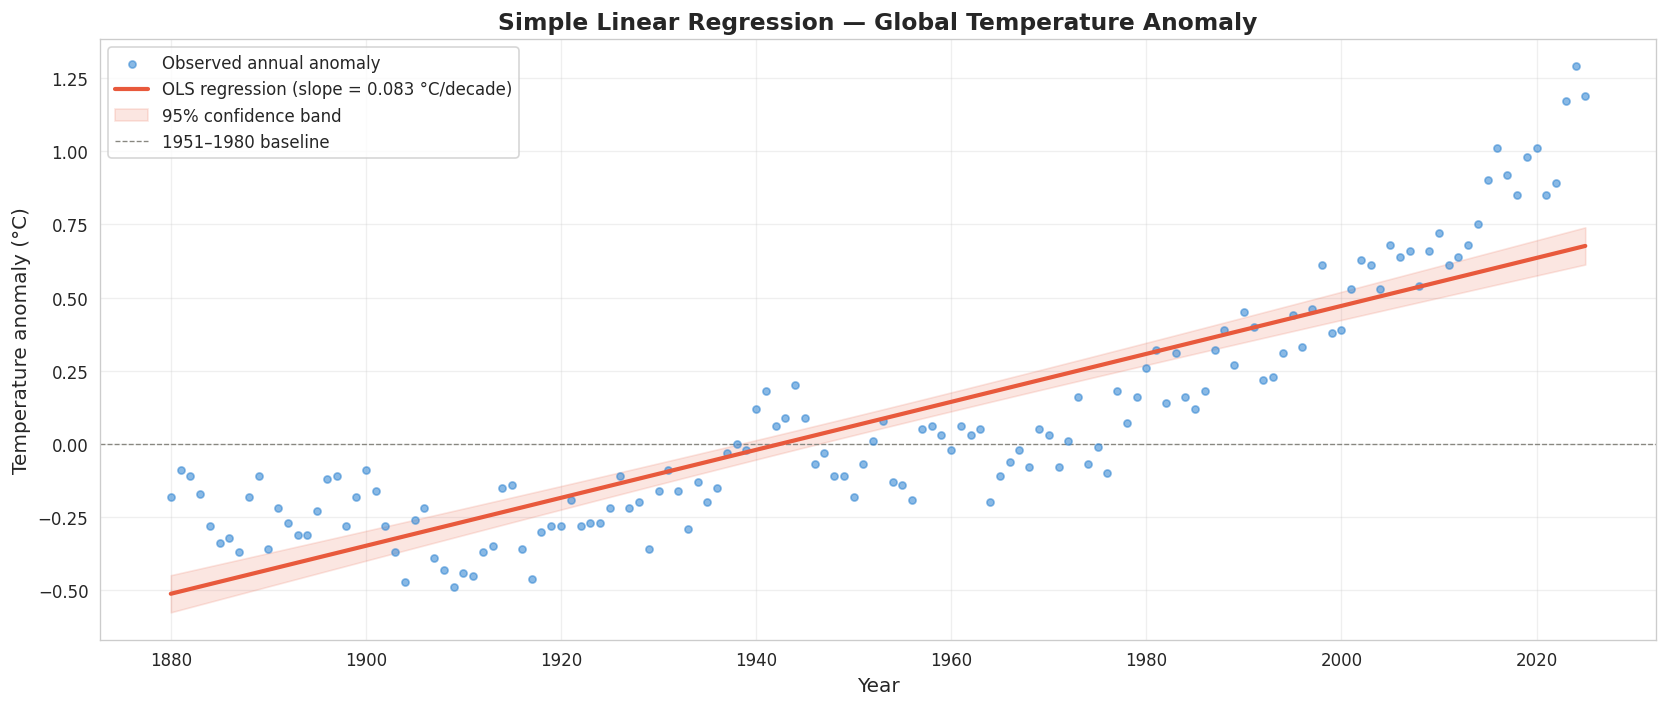

In [17]:
# =============================================================================
# SECTION 12: VISUALISATION — PLOT 1: REGRESSION LINE OVER DATA
# =============================================================================

def plot_regression_line(df, X, model, target_col, sig_results):
    """
    Plot the full dataset with the fitted regression line and
    95% confidence band.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    # Scatter: actual observations
    ax.scatter(df["Year"], df[target_col], s=18, alpha=0.6,
               color=COLOR_ACTUAL, label="Observed annual anomaly", zorder=3)

    # Regression line
    y_line = model.predict(X)
    ax.plot(df["Year"], y_line, color=COLOR_PREDICTED, linewidth=2.5,
            label=f"OLS regression (slope = {sig_results['slope']*10:.3f} °C/decade)",
            zorder=4)

    # 95% confidence band
    x_mean = df["Year"].mean()
    n = len(df)
    se_line = sig_results["std_err"] * np.sqrt(
        1/n + (df["Year"] - x_mean)**2 / np.sum((df["Year"] - x_mean)**2)
    )
    # Use residual standard error, not slope std error, for the band
    residuals_full = df[target_col].values - y_line
    s_residual = np.sqrt(np.sum(residuals_full**2) / (n - 2))
    se_pred = s_residual * np.sqrt(
        1/n + (df["Year"] - x_mean)**2 / np.sum((df["Year"] - x_mean)**2)
    )
    t_crit = stats.t.ppf(0.975, df=n-2)
    ax.fill_between(df["Year"],
                     y_line - t_crit * se_pred,
                     y_line + t_crit * se_pred,
                     alpha=0.15, color=COLOR_CI, label="95% confidence band")

    # Baseline
    ax.axhline(0, color=COLOR_BASELINE, linewidth=0.8, linestyle="--",
               label="1951–1980 baseline")

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Temperature anomaly (°C)", fontsize=12)
    ax.set_title("Simple Linear Regression — Global Temperature Anomaly",
                 fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=10)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_regression_line(df, X, model, TARGET_COL, sig_results)


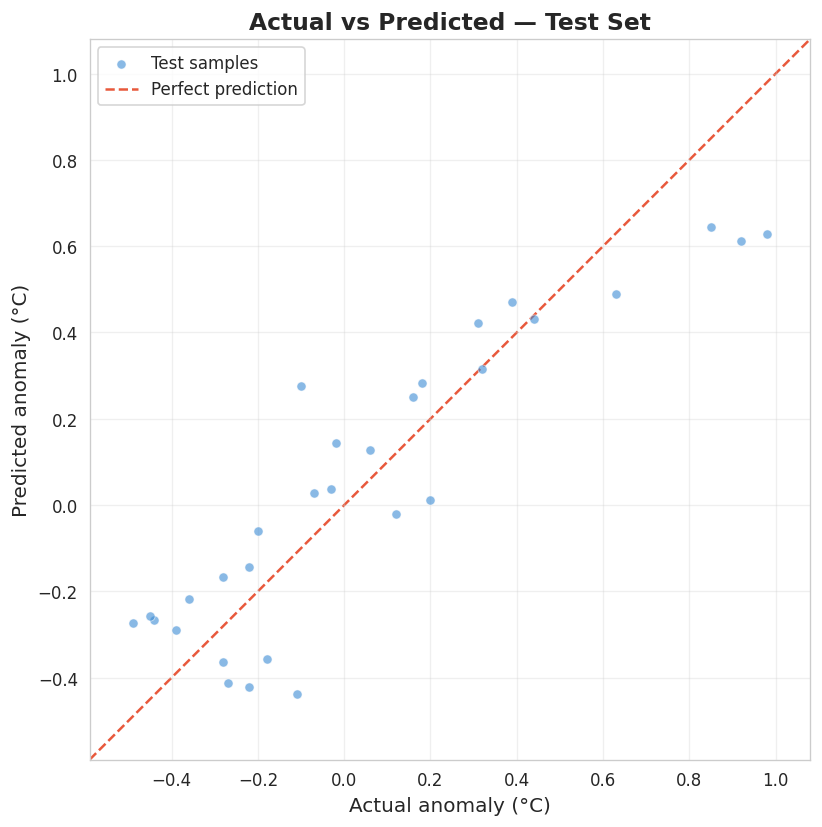

In [18]:
# =============================================================================
# SECTION 13: VISUALISATION — PLOT 2: ACTUAL vs PREDICTED
# =============================================================================

def plot_actual_vs_predicted(y_test, y_pred):
    """
    Scatter plot of actual vs predicted values on the test set.
    Points on the red diagonal line = perfect predictions.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(y_test, y_pred, s=30, alpha=0.6, color=COLOR_ACTUAL,
               edgecolor="white", linewidth=0.5, label="Test samples")

    # Perfect prediction line (45° diagonal)
    lims = [min(y_test.min(), y_pred.min()) - 0.1,
            max(y_test.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, color=COLOR_PREDICTED, linewidth=1.5,
            linestyle="--", label="Perfect prediction", zorder=0)

    ax.set_xlabel("Actual anomaly (°C)", fontsize=12)
    ax.set_ylabel("Predicted anomaly (°C)", fontsize=12)
    ax.set_title("Actual vs Predicted — Test Set", fontsize=14, fontweight="bold")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(y_test, y_test_pred)


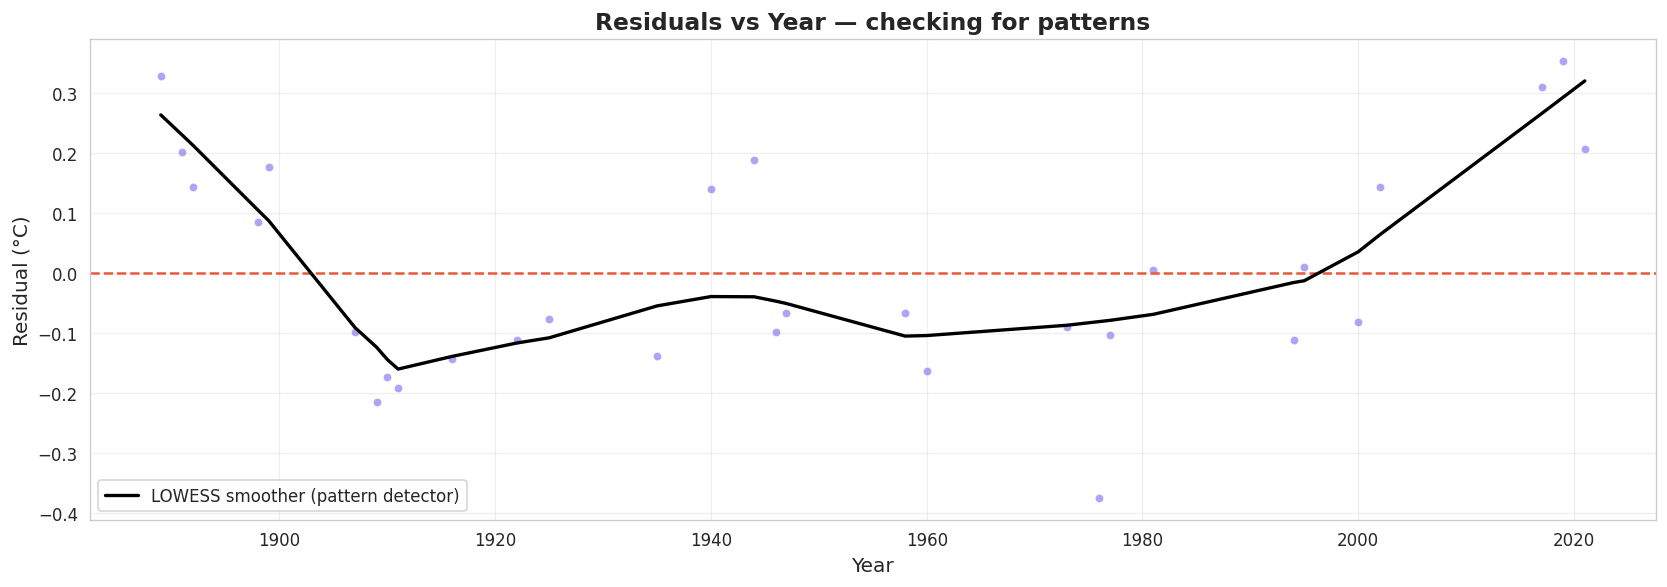

HOW TO READ THIS PLOT:
  • Random scatter around 0 → linearity assumption holds ✓
  • U-shaped or curved pattern → non-linear trend; try polynomial ✗
  • Funnel shape (wider on one side) → heteroscedasticity ✗
  • If LOWESS line deviates from 0 → model is systematically wrong there


In [19]:
# =============================================================================
# SECTION 14: VISUALISATION — PLOT 3: RESIDUALS vs YEAR
# =============================================================================

def plot_residuals_vs_feature(X_test, residuals, feature_name="Year"):
    """
    Plot residuals against the predictor variable.
    A random scatter around 0 = good. A pattern = problem.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.scatter(X_test[feature_name], residuals, s=25, alpha=0.6,
               color=COLOR_RESIDUAL, edgecolor="white", linewidth=0.5)

    # Zero line
    ax.axhline(0, color=COLOR_PREDICTED, linewidth=1.5, linestyle="--")

    # LOWESS smoothing to detect hidden patterns
    from statsmodels.nonparametric.smoothers_lowess import lowess
    try:
        sorted_pairs = sorted(zip(X_test[feature_name].values, residuals))
        x_sorted = [p[0] for p in sorted_pairs]
        r_sorted = [p[1] for p in sorted_pairs]
        smoothed = lowess(r_sorted, x_sorted, frac=0.3)
        ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2,
                label="LOWESS smoother (pattern detector)")
    except ImportError:
        print("Note: Install statsmodels for LOWESS smoother: pip install statsmodels")

    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel("Residual (°C)", fontsize=12)
    ax.set_title("Residuals vs Year — checking for patterns",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Interpretation guide
    print("HOW TO READ THIS PLOT:")
    print("  • Random scatter around 0 → linearity assumption holds ✓")
    print("  • U-shaped or curved pattern → non-linear trend; try polynomial ✗")
    print("  • Funnel shape (wider on one side) → heteroscedasticity ✗")
    print("  • If LOWESS line deviates from 0 → model is systematically wrong there")


residuals = diagnostics["residuals"]
plot_residuals_vs_feature(X_test, residuals, feature_name="Year")


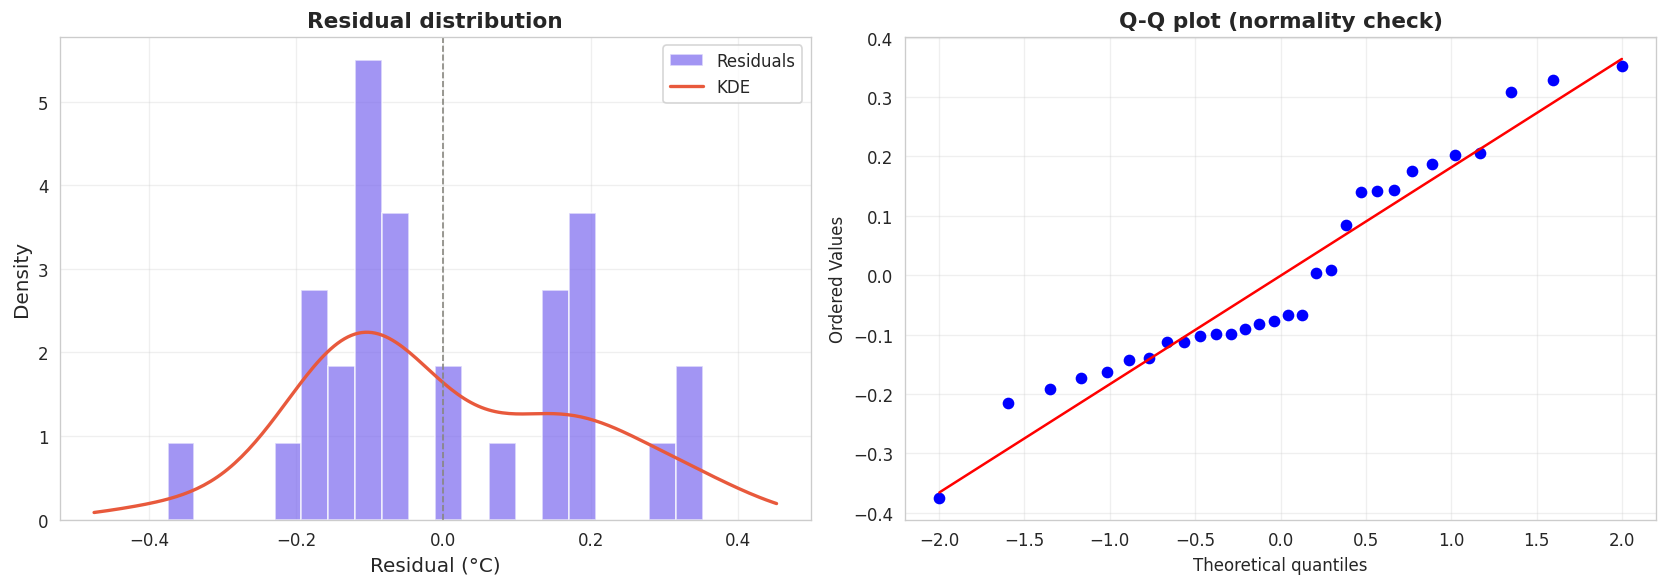

HOW TO READ THESE PLOTS:
  Histogram  : Should be roughly bell-shaped and centred at 0
  Q-Q plot   : Points on the red line = normally distributed residuals
               Deviations at the tails = heavier/lighter tails than normal


In [20]:
# =============================================================================
# SECTION 15: VISUALISATION — PLOT 4: RESIDUAL DISTRIBUTION
# =============================================================================

def plot_residual_distribution(residuals):
    """
    Histogram with KDE and Q-Q plot of residuals to check normality.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Histogram + KDE ---
    axes[0].hist(residuals, bins=20, color=COLOR_RESIDUAL, alpha=0.7,
                 edgecolor="white", density=True, label="Residuals")
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(residuals)
    x_range = np.linspace(residuals.min() - 0.1, residuals.max() + 0.1, 200)
    axes[0].plot(x_range, kde(x_range), color=COLOR_PREDICTED, linewidth=2,
                 label="KDE")
    axes[0].axvline(0, color=COLOR_BASELINE, linewidth=1, linestyle="--")
    axes[0].set_xlabel("Residual (°C)", fontsize=12)
    axes[0].set_ylabel("Density", fontsize=12)
    axes[0].set_title("Residual distribution", fontsize=13, fontweight="bold")
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)

    # --- Q-Q Plot ---
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q plot (normality check)", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("HOW TO READ THESE PLOTS:")
    print("  Histogram  : Should be roughly bell-shaped and centred at 0")
    print("  Q-Q plot   : Points on the red line = normally distributed residuals")
    print("               Deviations at the tails = heavier/lighter tails than normal")


plot_residual_distribution(residuals)


---
## Step 10 — Consolidated results summary

All metrics in one table for easy reference and comparison with later notebooks.


In [21]:
# =============================================================================
# SECTION 16: RESULTS SUMMARY TABLE
# =============================================================================

def build_results_summary(model_name, test_metrics, cv_results, sig_results):
    """
    Build a single-row DataFrame summarising model performance.
    This format is designed to be concatenated across notebooks
    for the final model comparison in Notebook 07.

    Returns
    -------
    pd.DataFrame
        One-row summary of all key results.
    """
    summary = pd.DataFrame([{
        "Model": model_name,
        "Features": "Year",
        "R² (test)": test_metrics["R²"],
        "Adj R² (test)": test_metrics["Adjusted R²"],
        "RMSE (test)": test_metrics["RMSE (°C)"],
        "MAE (test)": test_metrics["MAE (°C)"],
        "CV RMSE (mean)": cv_results["rmse_mean"],
        "CV RMSE (std)": cv_results["rmse_std"],
        "CV R² (mean)": cv_results["r2_mean"],
        "Slope (°C/yr)": sig_results["slope"],
        "Slope p-value": sig_results["p_value"],
        "Slope 95% CI lower": sig_results["ci_lower"],
        "Slope 95% CI upper": sig_results["ci_upper"],
        "Durbin-Watson": diagnostics["durbin_watson"]
    }])
    return summary


results_nb02 = build_results_summary(
    model_name="Simple Linear Regression (OLS)",
    test_metrics=test_metrics,
    cv_results=cv_results,
    sig_results=sig_results
)

# Display transposed for readability
print("\n" + "=" * 60)
print("NOTEBOOK 02 — RESULTS SUMMARY")
print("=" * 60)
print(results_nb02.T.to_string(header=False))

# Save for use in Notebook 07
results_nb02.to_csv("results_nb02.csv", index=False)
print("\n→ Results saved to results_nb02.csv for Notebook 07 comparison.")



NOTEBOOK 02 — RESULTS SUMMARY
Model               Simple Linear Regression (OLS)
Features                                      Year
R² (test)                                   0.8044
Adj R² (test)                               0.7974
RMSE (test)                                 0.1780
MAE (test)                                  0.1533
CV RMSE (mean)                              0.2175
CV RMSE (std)                               0.1154
CV R² (mean)                               -3.3059
Slope (°C/yr)                               0.0083
Slope p-value                               0.0000
Slope 95% CI lower                          0.0075
Slope 95% CI upper                          0.0091
Durbin-Watson                               0.6450

→ Results saved to results_nb02.csv for Notebook 07 comparison.


---
## Inferences and conclusions

### Answering Research Question RQ1

> *Is there a statistically significant linear trend in global temperature anomaly from 1880 to 2024?*

**Record your findings below after running all cells:**

| Question | Your finding |
|---|---|
| Is the slope significant? | p-value = ___ → Yes / No |
| What is the warming rate? | ___ °C per decade |
| 95% CI for the slope | [___ , ___] °C per year |
| How much variance does Year explain? | R² = ___ |
| Does the model generalise well? | Train R² = ___ vs Test R² = ___ |
| Are residuals well-behaved? | Normality: ___ / Autocorrelation: ___ |

### Testing Hypothesis H1

> **H1:** Global mean surface temperature anomaly has a statistically significant positive linear relationship with time.

**Your conclusion:** (Fill in after running)
- If p-value < 0.05 and slope > 0 → **H1 is supported**
- The data shows [___]°C warming per decade, with 95% confidence that the true rate falls between [___] and [___] °C per decade.

### Limitations of simple linear regression for this data

1. **Linearity assumption may be violated** — if the residual plot shows a curved pattern, the warming rate is not constant. This motivates Notebook 04 (polynomial regression).

2. **Autocorrelation** — if Durbin-Watson < 1.5, consecutive years are not independent. This is expected for climate data and means our standard errors may be underestimated.

3. **Single predictor** — Year is a proxy for time, not a cause of warming. The actual drivers (CO₂, land use, solar activity) are explored in Notebook 03 (multiple regression).

4. **Extrapolation risk** — predictions for 2030+ assume the trend continues linearly. The acceleration visible in recent decades suggests polynomial or more complex models may be more appropriate for projection.

### What to do next

- **If residuals show a curve** → proceed to Notebook 04 (Polynomial Regression) to test H2
- **If R² is high but DW is low** → proceed to Notebook 03 (add lag features to handle autocorrelation)
- **Regardless** → proceed to Notebook 03 to test whether feature engineering improves the model

---

*End of Notebook 02. Proceed to `03_multiple_regression.ipynb`.*
